***Import libraires and data, set up stuff***

In [1]:
%run ../Script/analysisLibraries

In [2]:
%run ../Script/pythonScripts.py

In [3]:
%matplotlib inline

In [4]:
%load_ext rpy2.ipython

In [5]:
import topo as tp

In [6]:
rcParams['figure.figsize']=(6,6) #rescale figures

In [8]:
nucData = sc.read(f'../nuclei_analysis/write/adata.norm.topo.clst.h5ad')

Only considering the two last: ['.clst', '.h5ad'].
Only considering the two last: ['.clst', '.h5ad'].


In [9]:
cellData = sc.read(f'../cells_analysis/write/adata.norm.topo.clst.h5ad')

Only considering the two last: ['.clst', '.h5ad'].
Only considering the two last: ['.clst', '.h5ad'].


In [10]:
adata = ad.AnnData.concatenate(nucData, cellData, batch_categories=["Nuclei","Cells"])

In [11]:
adata.obs['clusters_single'].cat.categories

Index(['Diplotene', 'Elong.Spt', 'Endothelial', 'Leptotene', 'Myoid',
       'Pachytene', 'Round.Spt', 'SpermatogoniaA', 'SpermatogoniaB',
       'Zygotene'],
      dtype='object')

In [12]:
adata = adata[ [i not in ['Somatic', 'Endothelial', 'Sertoli'] 
                for i in adata.obs['clusters_single']] ].copy()

In [13]:
clusters = adata.obs['clusters_single'].copy()

In [14]:
clusters_grouped = [i if i not in ['Leptotene', 'Pachytene', 'Diplotene', 'Zygotene'] 
                    else 'Spermatocites'
                    for i in clusters]

In [15]:
adata.obs['clusters_compact'] = pd.Categorical(clusters_grouped)

In [16]:
#adata.obsm['X_pca_single'] = adata.obsm['X_pca'].copy()

Normalization with SCtransform

In [17]:
adata

AnnData object with n_obs × n_vars = 10448 × 23544
    obs: 'spl_prop', 'uns_prop', 'perc_rp', 'perc_mito', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'perc_PRM1', 'perc_PRM2', 'perc_LOC104001214', 'perc_KEF41-p07', 'perc_KEF41-p04', 'perc_MTRNR2L14', 'genes_threshold_filter', 'all_filters', 'correction_quantity', 'leiden', 'doublet_score', 'predicted_doublet', 'bw_adaptive from LE with bw_adaptive_leiden', 'bw_adaptive from DM with bw_adaptive_leiden', 'topo_leiden_LE', 'topo_leiden_DM', 'SpermatogoniaA_score', 'SpermatogoniaB_score', 'Round.Spt_score', 'Elong.Spt_score', 'Sertoli_score', 'Macroph_score', 'Endothelial_score', 'Myoid_score', 'Smooth_Muscle_score', 'Leptotene_score', 'Zygotene_score', 'Pachytene_score', 'Diplotene_score', 'clusters_single', 'perc_TNP1', 'perc_HSP90AA1', 'batch', 'clusters_compact'
    var: 

In [18]:
rawMatrix = adata.layers['soupx_counts'].T
cells = adata.obs_names
genes = adata.var_names
dataset = np.array(adata.obs["batch"]) #batch
perc_mito = np.array(adata.obs["perc_mito"]) #batch
perc_rp = np.array(adata.obs["perc_rp"]) #batch
spl_prop = np.array(adata.obs["spl_prop"]) #batch

In [19]:
%%R -i rawMatrix -i cells -i genes -o norm_sct -o umi_corr -o genes_var -o variance -i dataset -i perc_rp -i perc_mito -i spl_prop
library(Seurat)
colnames(rawMatrix) <- cells
rownames(rawMatrix) <- genes
meta <- data.frame(dataset = dataset, perc_rp = perc_rp, perc_mito = perc_mito, spl_prop=spl_prop) #with batch

print(dim(rawMatrix))
seurat_df <- CreateSeuratObject(rawMatrix)
seurat_df <- AddMetaData(seurat_df, meta$dataset, col.name = "dataset")
seurat_df <- AddMetaData(seurat_df, meta$perc_rp, col.name = "perc_rp")
seurat_df <- AddMetaData(seurat_df, meta$perc_mito, col.name = "perc_mito")
seurat_df <- AddMetaData(seurat_df, meta$spl_prop, col.name = "spl_prop")

# scTransform
#seurat_df <- SCTransform(seurat_df, verbose = TRUE, variable.features.n = length(genes), vars.to.regress = c("DATASET"), return.only.var.genes=FALSE)
seurat_df <- SCTransform(seurat_df, verbose = TRUE, ncells=length(cells), variable.features.n = 15000, batch_var = "dataset",  return.only.var.genes=FALSE)
# Get matrix of residuals
norm_sct <- GetAssayData(seurat_df,assay="SCT",slot="scale.data")
umi_corr <- GetAssayData(seurat_df,assay="SCT",slot="counts")
genes_var <- rownames(seurat_df$SCT)
variance = seurat_df$SCT@SCTModel.list$model1@feature.attributes$variance


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

R[write to console]: Attaching SeuratObject



[1] 23544 10448


R[write to console]: Calculating cell attributes from input UMI matrix: log_umi

R[write to console]: Variance stabilizing transformation of count matrix of size 23544 by 10448

R[write to console]: Model formula is y ~ (log_umi) : dataset + dataset + 0

R[write to console]: Get Negative Binomial regression parameters per gene

R[write to console]: Using 2000 genes, 10448 cells



  |======================================================================| 100%


R[write to console]: Found 13 outliers - those will be ignored in fitting/regularization step


R[write to console]: Second step: Get residuals using fitted parameters for 23544 genes



  |======================================================================| 100%


R[write to console]: Computing corrected count matrix for 23544 genes



  |======================================================================| 100%


R[write to console]: Calculating gene attributes

R[write to console]: Wall clock passed: Time difference of 1.32935 mins

R[write to console]: Determine variable features

R[write to console]: Place corrected count matrix in counts slot

R[write to console]: Centering data matrix

  |                                                                            
  |                                                                      |   0%
  |                                                                            
  |==                                                                    |   3%
  |                                                                            
  |====                                                                  |   6%
  |                                                                            
  |=======                                                               |   9%
  |                                                                          

Reintegrating into annotated data layers

In [20]:
adata = adata[:, genes_var].copy()

In [21]:
adata.layers['SCT_counts'] = norm_sct.T.copy()

In [22]:
adata.layers['correct_counts'] = umi_corr.T.copy()

In [23]:
adata.var['variance']=variance

In [24]:
del adata.obs['predicted_doublet']

In [25]:
!mkdir -p write

adata.write(f'./write/adata.norm.1.h5ad')

# Topometry

In [26]:
adata = sc.read(f'./write/adata.norm.1.h5ad')

Only considering the two last: ['.1', '.h5ad'].
Only considering the two last: ['.1', '.h5ad'].


<Axes: xlabel='variance', ylabel='Count'>

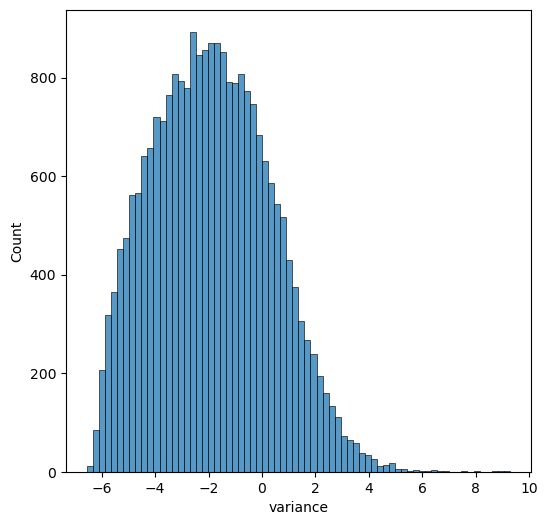

In [27]:
sns.histplot( np.log(adata.var['variance']))

In [28]:
adata.var_names[ np.log(adata.var['variance'])>-2  ]

Index(['A2ML1', 'AAAS', 'AACS', 'AAGAB', 'AAK1', 'AAMDC', 'AAMP', 'AANAT',
       'AAR2', 'AARS',
       ...
       'ZSWIM9', 'ZUP1', 'ZW10', 'ZWILCH', 'ZWINT', 'ZXDC', 'ZYG11A', 'ZYG11B',
       'ZZEF1', 'ZZZ3'],
      dtype='object', length=11941)

In [29]:
adata.var['highly_variable'] = (adata.var['highly_variable-Cells']) & (adata.var['highly_variable-Nuclei'])

In [30]:
#adata.var['highly_variable'] = [ i in adata.var_names[ np.log(adata.var['variance'])>-2 ] 
#                                 for i in adata.var_names ]

In [31]:
np.sum(adata.var['highly_variable'])

3160

Calculate intrinsic dimensionality

In [32]:
adataHVG = adata[:, adata.var.highly_variable].copy()

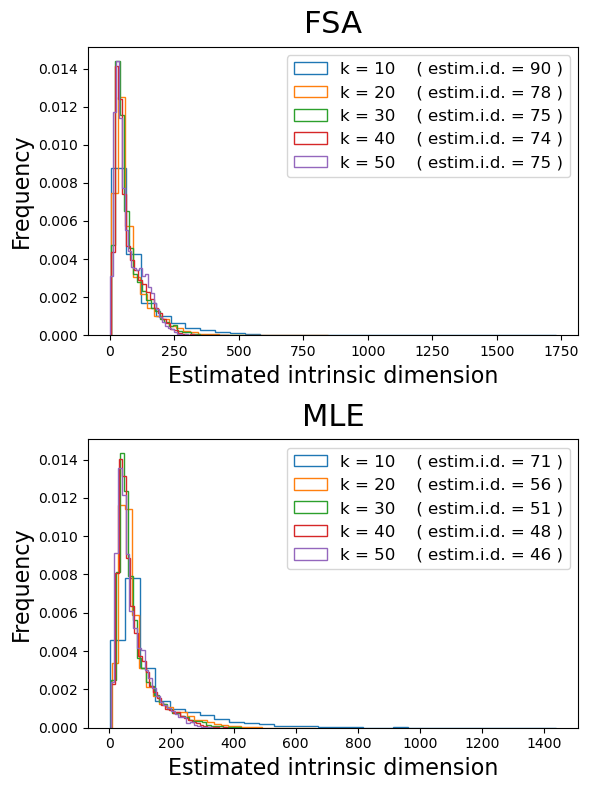

In [33]:
plt.rcParams["figure.figsize"] = (4, 4)
tp.tpgraph.IntrinsicDim(
    methods=["fsa", "mle"],
    k=range(10, 60, 10),
    backend="hnswlib",
    metric="euclidean",
    n_jobs=-1,
    plot=True,
    random_state=123,
).fit(adataHVG.X)

Calculating the Laplace Beltrami Operator

In [34]:
# Run TopOMetry

# Create a TopOGraph object with the desired parameters
tg = tp.TopOGraph(n_eigs=50, n_jobs=-1, verbosity=1, random_state=42)

# Fit some models to the data
adata = tp.sc.topological_workflow(
    adata,
    tg,
    kernels=["bw_adaptive"],
    eigenmap_methods=["LE","DM"],
    projections=["MAP", "PaCMAP"],
    resolution=0.5,
)

Computing neighborhood graph...
 Base kNN graph computed in 47.157195 (sec)
 Fitted the bw_adaptive kernel in 0.219538 (sec)
Computing eigenbasis...
 Fitted eigenbasis with Laplacian Eigenmaps from the bw_adaptive in 0.318075 (sec)
    Building topological graph from eigenbasis...
        Computing neighborhood graph...
 Computed in 0.235202 (sec)
 Fitted the bw_adaptive graph kernel in 0.219519 (sec)
 Computed MAP in 7.582742 (sec)
 Computed PaCMAP in 9.567662 (sec)
Computing eigenbasis...
 Fitted eigenbasis with Diffusion Maps from the bw_adaptive kernel in 0.179566 (sec)
    Building topological graph from eigenbasis...
        Computing neighborhood graph...
 Computed in 0.223843 (sec)
 Fitted the bw_adaptive graph kernel in 0.225423 (sec)
 Computed MAP in 9.468894 (sec)
 Computed PaCMAP in 9.374662 (sec)


outputs from topometry

In [35]:
adata.obsm

AxisArrays with keys: X_DM, X_DM with bw_adaptive, X_LE, X_LE with bw_adaptive, X_MAP of bw_adaptive from DM with bw_adaptive, X_MAP of bw_adaptive from LE with bw_adaptive, X_PaCMAP of DM with bw_adaptive, X_PaCMAP of LE with bw_adaptive, X_pca, X_topoMAP_DM, X_topoMAP_LE, X_topoPaCMAP_DM, X_topoPaCMAP_LE, X_umap

In [36]:
adata.obsm["X_topoMAP_LE_merge"] = adata.obsm["X_MAP of bw_adaptive from LE with bw_adaptive"]
adata.obsm["X_topoPaCMAP_LE_merge"] = adata.obsm["X_PaCMAP of LE with bw_adaptive"]
adata.obs["topo_leiden_LE_merge"] = adata.obs["bw_adaptive from LE with bw_adaptive_leiden"]

adata.obsm["X_topoMAP_DM_merge"] = adata.obsm["X_MAP of bw_adaptive from DM with bw_adaptive"]
adata.obsm["X_topoPaCMAP_DM_merge"] = adata.obsm["X_PaCMAP of DM with bw_adaptive"]
adata.obs["topo_leiden_DM_merge"] = adata.obs["bw_adaptive from DM with bw_adaptive_leiden"]

adata.obsm["X_LE_merge"] = adata.obsm["X_LE with bw_adaptive"]
adata.obsm["X_DM_merge"] = adata.obsm["X_DM with bw_adaptive"]

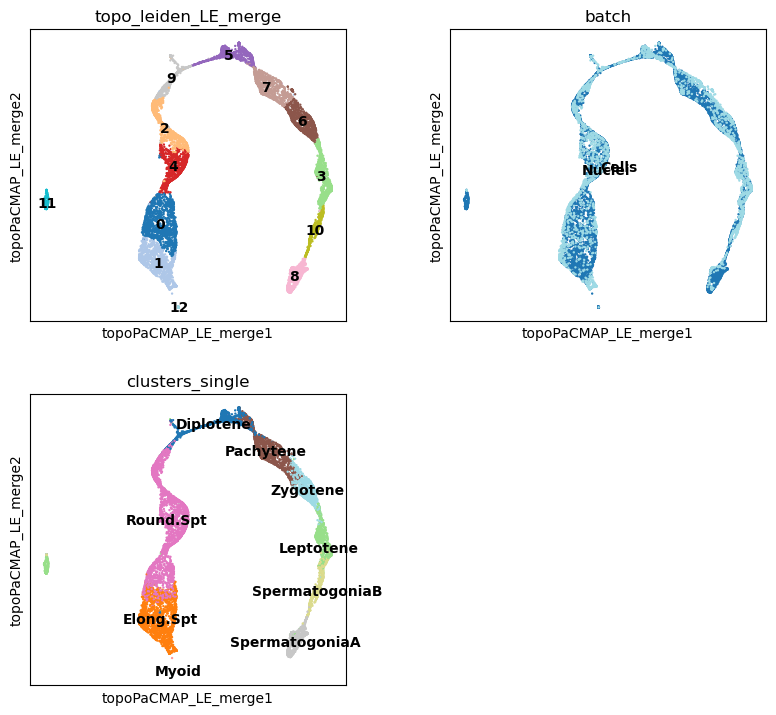

In [37]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE_merge",
    color=["topo_leiden_LE_merge","batch", 'clusters_single'],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

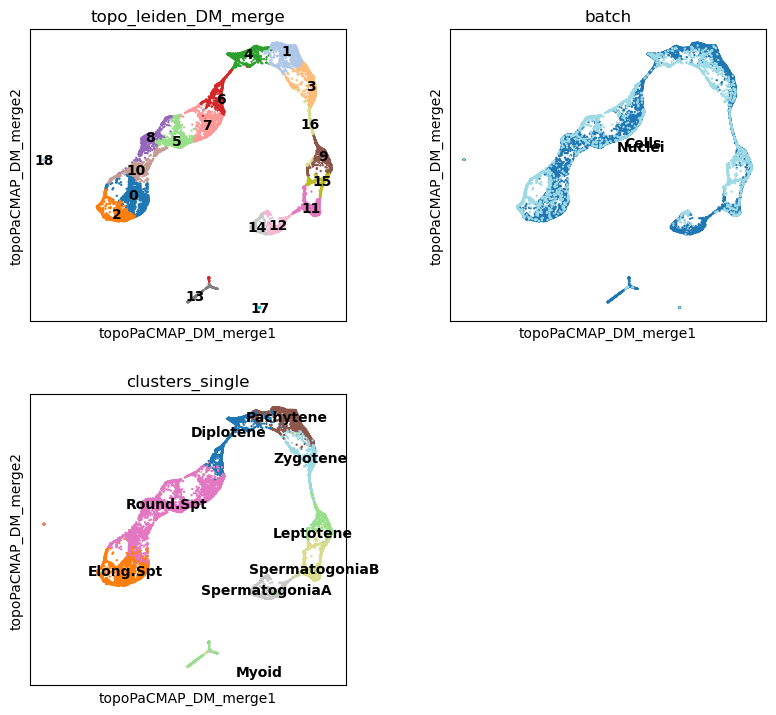

In [38]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_DM_merge",
    color=["topo_leiden_DM_merge","batch",'clusters_single'],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

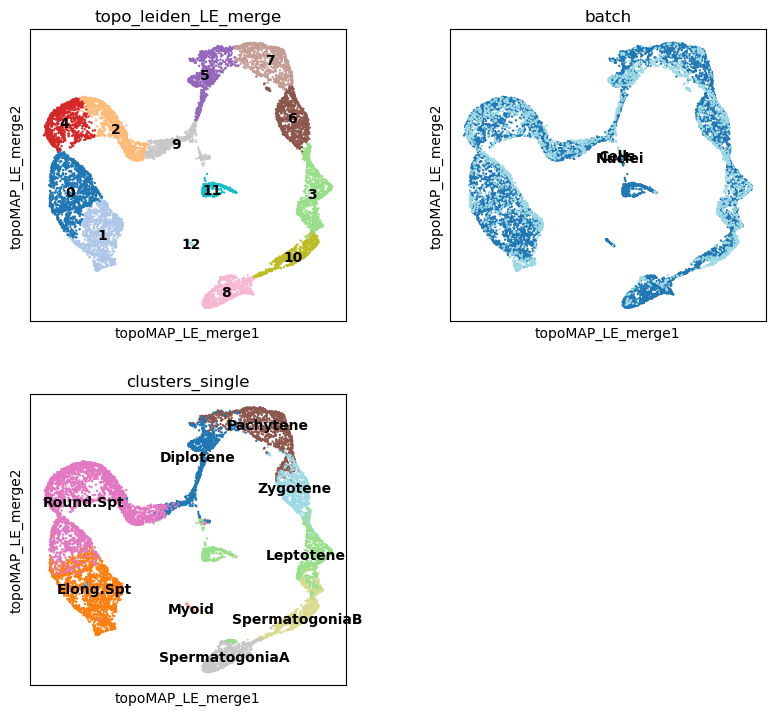

In [39]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoMAP_LE_merge",
    color=["topo_leiden_LE_merge","batch",'clusters_single'],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

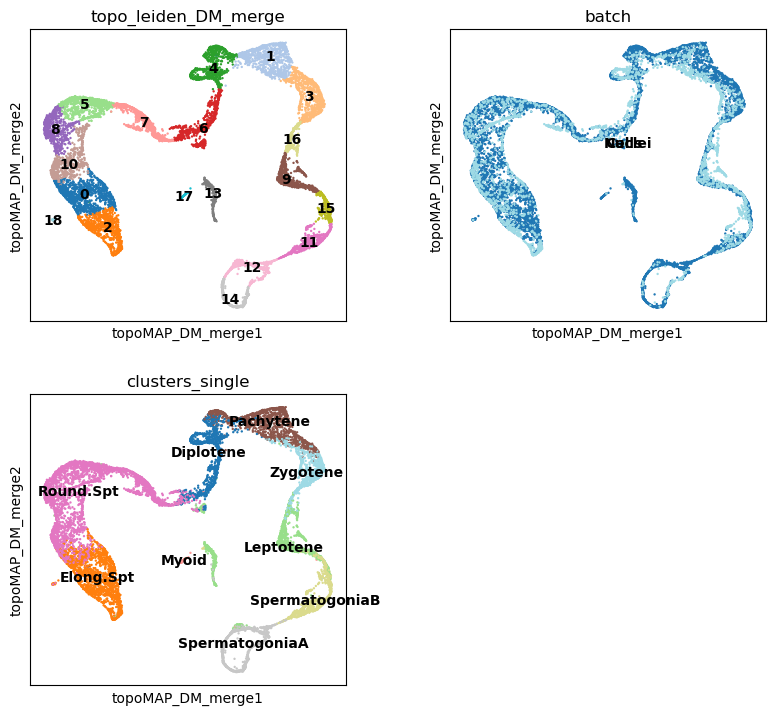

In [40]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoMAP_DM_merge",
    color=["topo_leiden_DM_merge","batch",'clusters_single'],
    palette="tab20",
    ncols=2,
    legend_loc="on data",
    legend_fontsize=10,
)

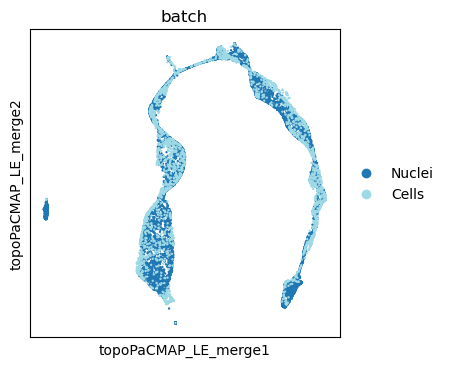

In [41]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE_merge",
    color=["batch"],
    palette="tab20",
    ncols=2,
    legend_fontsize=10,
)

In [42]:
adata.write(f'./write/adata.norm.topo.h5ad')

In [72]:
adata = sc.read(f'./write/adata.norm.topo.h5ad')

Only considering the two last: ['.topo', '.h5ad'].
Only considering the two last: ['.topo', '.h5ad'].


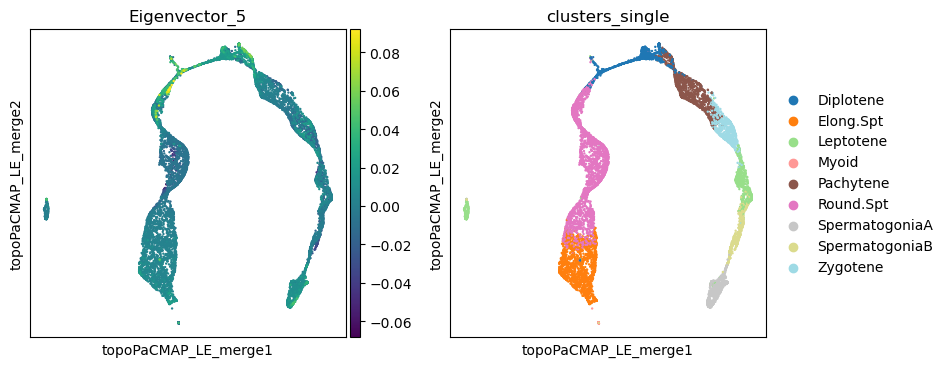

Scores of component 5 by cluster


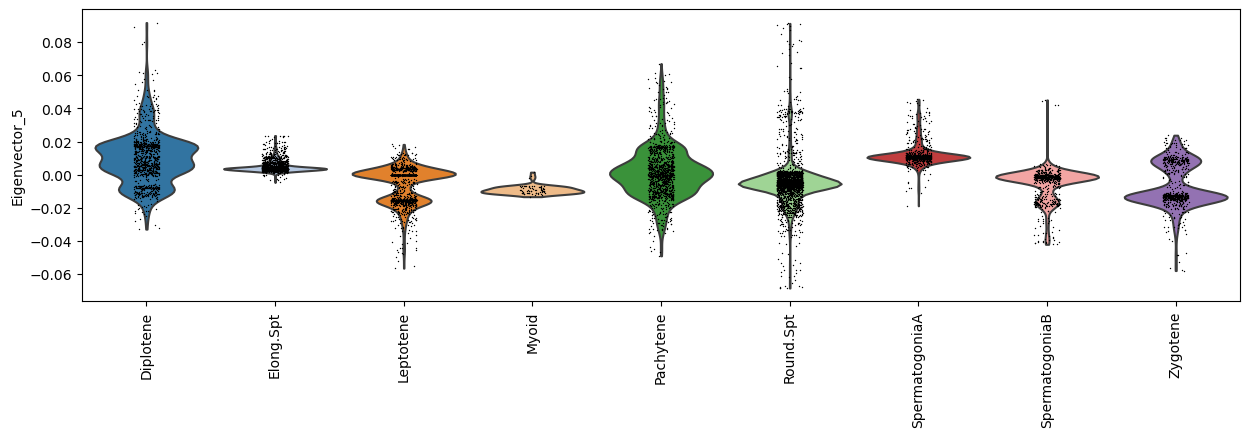

In [73]:
component = 5

adata.obs[f"Eigenvector_{component}"] = adata.obsm["X_LE"][:, component]

plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE_merge",
    color=[f"Eigenvector_{component}", "clusters_single"],
    palette="tab20",
    ncols=3,
    legend_fontsize=10,
)

plt.rcParams["figure.figsize"] = (12, 4)
print(f"Scores of component {component} by cluster")
f = sc.pl.violin(
    adata,
    keys=[f"Eigenvector_{component}"],
    groupby="clusters_single",
    palette="tab20",
    rotation=90,
)

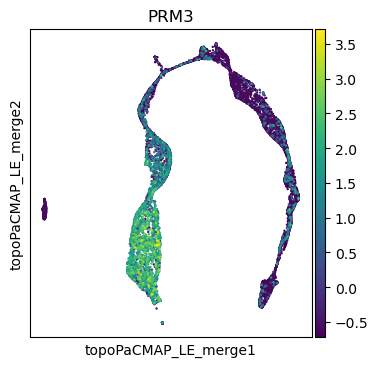

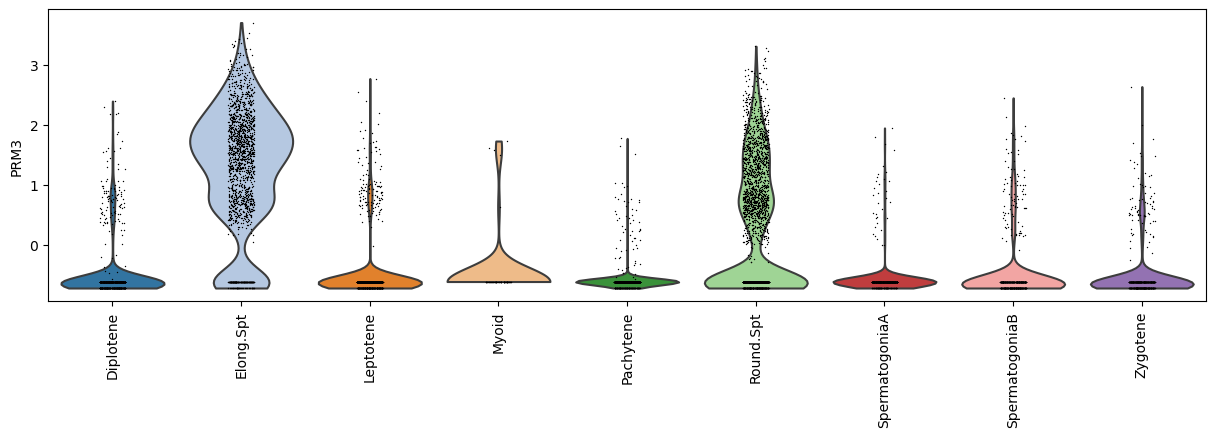

In [74]:
G="PRM3"

plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(
    adata,
    basis="topoPaCMAP_LE_merge",
    color=[G],
    palette="tab20",
    ncols=3,
    legend_fontsize=10,
)

plt.rcParams["figure.figsize"] = (12, 4)
f = sc.pl.violin(
    adata,
    keys=[G],
    groupby="clusters_single",
    palette="tab20",
    rotation=90,
)

In [75]:
adata.write(f'./write/adata.norm.topo.1.h5ad')

## Plotting a plot with proportions of cell types

In [52]:
adata=sc.read(f'./write/adata.norm.topo.1.h5ad')

Only considering the two last: ['.1', '.h5ad'].
Only considering the two last: ['.1', '.h5ad'].


In [53]:
adata = adata[ [i not in ['13','17','18'] for i in adata.obs.topo_leiden_DM_merge] ]

In [54]:
cells = adata[ adata.obs['batch']=='Cells' ]
nuclei = adata[ adata.obs['batch']=='Nuclei' ]

In [55]:
df = pd.DataFrame(columns=['Cluster','Proportion','Samples'])
cluster = list()
proportion = list()
sample = list()
for n in range(10):
    cells_sub = sc.pp.subsample(cells, random_state=n, fraction=.10, copy=True)
    P = cells_sub.obs['clusters_single'].value_counts() / cells_sub.shape[0]
    cluster.append( P.index )
    proportion.append( P.values )
    sample.append( ['Cells']*len(P) )

    nuc_sub = sc.pp.subsample(nuclei, random_state=n, fraction=.10, copy=True)
    P = nuc_sub.obs['clusters_single'].value_counts() / nuc_sub.shape[0]
    cluster.append( P.index )
    proportion.append( P.values )
    sample.append( ['Nuclei']*len(P) )

In [56]:
df['Cluster'] = np.hstack(cluster)
df['Proportion'] = np.hstack(proportion)
df['Samples'] = np.hstack(sample)

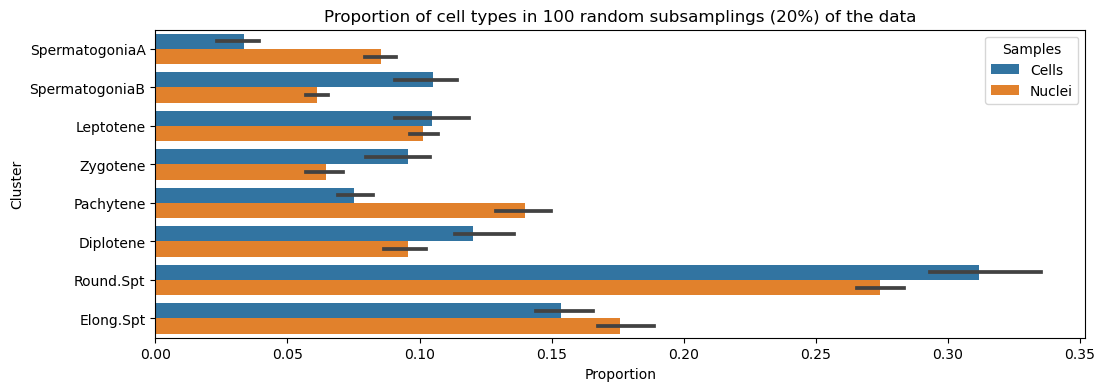

In [57]:
f = sns.barplot(data=df, y="Cluster", x="Proportion", hue="Samples", order=['SpermatogoniaA','SpermatogoniaB', 'Leptotene', 'Zygotene','Pachytene','Diplotene','Round.Spt',
                   'Elong.Spt'],errorbar=("pi", 50) )
title=f.set_title("Proportion of cell types in 100 random subsamplings (20%) of the data")

# Cluster similarity

Creating matrix for integrated PCA and individual clustering. Use compact clustering.

In [58]:
cells = adata[ adata.obs['batch']=='Cells' ]
nuclei = adata[ adata.obs['batch']=='Nuclei' ]

In [59]:
adata.obs['clusters_single'].cat.categories

Index(['Diplotene', 'Elong.Spt', 'Leptotene', 'Myoid', 'Pachytene',
       'Round.Spt', 'SpermatogoniaA', 'SpermatogoniaB', 'Zygotene'],
      dtype='object')

In [61]:
Xcells = cells[:,cells.var['highly_variable']].layers['soupx_counts'].copy()
Xnuclei = nuclei[:,cells.var['highly_variable']].layers['soupx_counts'].copy()
DFall = pd.DataFrame()
cells_clst = cells.obs['clusters_single']
nuclei_clst = nuclei.obs['clusters_single']
for clst in ['SpermatogoniaA','SpermatogoniaB', 'Leptotene', 
              'Zygotene','Pachytene','Diplotene','Round.Spt',
              'Elong.Spt']:
    DFall[f'{clst}-cells'] = np.mean(Xcells[ cells_clst == clst, :], 0)
    DFall[f'{clst}-nuclei'] = np.mean(Xnuclei[ nuclei_clst == clst, :], 0)

In [62]:
DFall.head()

,SpermatogoniaA-cells,SpermatogoniaA-nuclei,SpermatogoniaB-cells,SpermatogoniaB-nuclei,Leptotene-cells,Leptotene-nuclei,Zygotene-cells,Zygotene-nuclei,Pachytene-cells,Pachytene-nuclei,Diplotene-cells,Diplotene-nuclei,Round.Spt-cells,Round.Spt-nuclei,Elong.Spt-cells,Elong.Spt-nuclei
0,0.136364,0.096573,0.000000,0.006865,0.107143,0.065621,0.000000,0.004515,0.000000,0.009937,0.069401,0.061111,0.446281,0.175884,0.007264,0.003968
1,0.193182,0.042056,0.059480,0.009153,0.192857,0.042796,0.112319,0.051919,0.134409,0.071364,0.779180,0.359722,0.317591,0.105630,0.065375,0.019048
2,0.193182,0.093458,0.130112,0.034325,0.153571,0.031384,0.101449,0.022573,0.118280,0.029810,0.454259,0.216667,0.434475,0.154958,0.082324,0.006349
3,1.568182,0.655763,1.423792,0.247140,0.975000,0.299572,0.318841,0.117381,0.032258,0.043360,0.056782,0.040278,0.597403,0.284006,0.077482,0.021429
4,0.125000,0.038941,0.014870,0.011442,0.189286,0.332382,0.036232,0.006772,0.059140,0.000000,0.041009,0.005556,0.020071,0.000000,0.016949,0.006349


In [63]:
corr_mat = DFall.corr().stack().reset_index(name="correlation")

In [64]:
corr_mat

,level_0,level_1,correlation
0,SpermatogoniaA-cells,SpermatogoniaA-cells,1.000000
1,SpermatogoniaA-cells,SpermatogoniaA-nuclei,0.898767
2,SpermatogoniaA-cells,SpermatogoniaB-cells,0.642840
3,SpermatogoniaA-cells,SpermatogoniaB-nuclei,0.710182
4,SpermatogoniaA-cells,Leptotene-cells,0.311550
...,...,...,...
251,Elong.Spt-nuclei,Diplotene-nuclei,0.125933
252,Elong.Spt-nuclei,Round.Spt-cells,0.494310
253,Elong.Spt-nuclei,Round.Spt-nuclei,0.487864
254,Elong.Spt-nuclei,Elong.Spt-cells,0.934753


In [65]:
corr_mat['level_0'] = np.array(corr_mat['level_0'], dtype='str')

In [66]:
idx = np.zeros(corr_mat.shape[0], dtype='bool8')
for i in range(corr_mat.shape[0]):
    idx[i] = (corr_mat.iloc[i,0].split('-')[1]=='cells')&(corr_mat.iloc[i,1].split('-')[1]=='nuclei')

In [67]:
corr_mat_2 = corr_mat.iloc[idx,:]

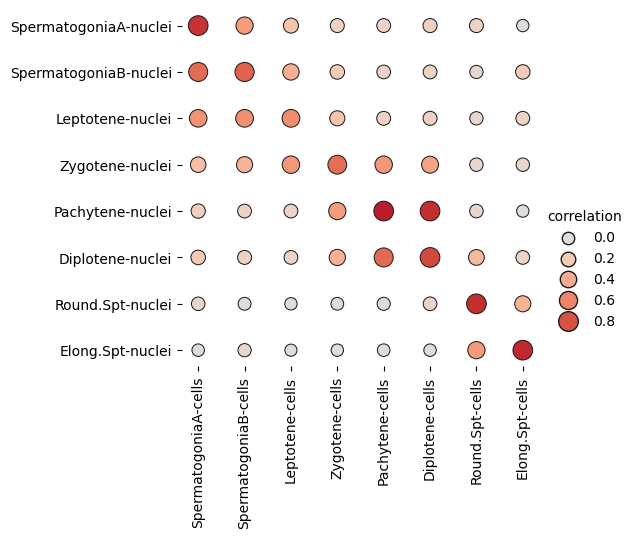

In [68]:
# Draw each cell as a scatter point with varying size and color
g = sns.relplot(
    data=corr_mat_2,
    x="level_0", y="level_1", hue="correlation", size="correlation",
    palette="coolwarm", hue_norm=(-1, 1), edgecolor=".1",
    height=6, sizes=(50, 200), size_norm=(-.2, .8)
)
# Tweak the figure to finalize
g.set(xlabel="", ylabel="", aspect="equal")
g.despine(left=True, bottom=True)
g.ax.margins(.05)
for label in g.ax.get_xticklabels():
    label.set_rotation(90)
for artist in g.legend.legendHandles:
    artist.set_edgecolor(".1")